# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [23]:
corpus = '''
formula one is the pinnacle of motorsport engineering and technology
formula one cars can reach speeds of over three hundred kilometres per hour
formula one racing demands exceptional skill from every driver on the grid
formula one teams spend millions developing faster and more aerodynamic cars
formula one engines produce over one thousand horsepower in modern hybrid era
formula one has been the ultimate racing championship since nineteen fifty
formula one circuits are designed to test both car and driver to the limit
formula one strategy involves tyre management fuel loads and pit stop timing
lewis hamilton has won seven formula one world championship titles in his career
lewis hamilton drives with incredible consistency and speed across all circuits
lewis hamilton joined mercedes and dominated formula one for nearly a decade
max verstappen became the youngest formula one world champion in history
max verstappen drives aggressively and extracts maximum performance from his car
max verstappen won the world championship with red bull racing team
ferrari is the most iconic team in formula one history and tradition
ferrari has competed in formula one since the very first season in nineteen fifty
ferrari engineers work tirelessly to improve car performance each race weekend
pit stops are critical moments that can decide the outcome of a formula one race
pit stops require perfect coordination between mechanics and race strategy team
pit stops last only a few seconds when executed with precision and practice
tyre strategy is one of the most important factors in formula one race outcomes
soft tyres provide more grip but degrade much faster than medium or hard tyres
hard tyres last longer but do not provide as much grip as soft compounds
the monaco grand prix is the slowest and most prestigious race in formula one
the monaco grand prix demands intense concentration on narrow and unforgiving streets
the monaco grand prix has been held since nineteen twenty nine on city streets
aerodynamics determine how much downforce a formula one car generates at speed
downforce pushes the car onto the track and allows higher cornering speeds
drs opens the rear wing and helps a driver overtake on straight sections
qualifying determines grid position and is crucial for race day strategy
safety car periods reset the race and give trailing teams a chance to recover
sector times allow engineers to understand where the car is losing or gaining time
the constructors championship rewards the team with the most accumulated points
formula one teams consist of hundreds of engineers mechanics and support staff
engine reliability is just as important as raw power in formula one racing
fuel loads at the race start affect car weight balance and early lap pace
formula one drivers train physically and mentally to handle extreme race conditions
overtaking in formula one requires bravery precise timing and good tyre life
the race start is one of the most dangerous and exciting moments in formula one
'''
print(corpus)


formula one is the pinnacle of motorsport engineering and technology
formula one cars can reach speeds of over three hundred kilometres per hour
formula one racing demands exceptional skill from every driver on the grid
formula one teams spend millions developing faster and more aerodynamic cars
formula one engines produce over one thousand horsepower in modern hybrid era
formula one has been the ultimate racing championship since nineteen fifty
formula one circuits are designed to test both car and driver to the limit
formula one strategy involves tyre management fuel loads and pit stop timing
lewis hamilton has won seven formula one world championship titles in his career
lewis hamilton drives with incredible consistency and speed across all circuits
lewis hamilton joined mercedes and dominated formula one for nearly a decade
max verstappen became the youngest formula one world champion in history
max verstappen drives aggressively and extracts maximum performance from his car
max v

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 246
X shape: (448, 14)
y shape: (448,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [25]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("RNN done | final loss:", round(rnn_history.history['loss'][-1], 4))

RNN done | final loss: 0.1119


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [26]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM done | final loss:", round(lstm_history.history['loss'][-1], 4))

LSTM done | final loss: 0.1254


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [27]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU done | final loss:", round(gru_history.history['loss'][-1], 4))

GRU done | final loss: 0.1105


## 📉 Compare Training Loss

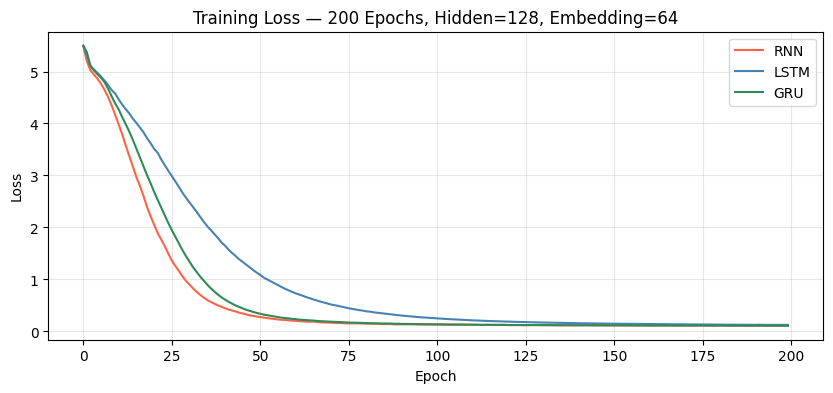

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'],  label='RNN',  color='tomato')
plt.plot(lstm_history.history['loss'], label='LSTM', color='steelblue')
plt.plot(gru_history.history['loss'],  label='GRU',  color='seagreen')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss — 200 Epochs, Hidden=128, Embedding=64")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [31]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

def generate_text(model, seed_text, next_words=10, temperature=0.9):
    result = seed_text
    recent_words = seed_text.split()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        if len(token_list) == 0:
            print("WARNING: seed text not found in vocabulary")
            break

        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        probs = model.predict(token_list, verbose=0)[0].astype('float64')

        probs = np.log(probs + 1e-7) / temperature
        probs = np.exp(probs) / np.sum(np.exp(probs))

        for word in recent_words[-3:]:
            idx = tokenizer.word_index.get(word)
            if idx is not None:
                probs[idx] *= 0.3
        probs = probs / np.sum(probs)

        predicted = np.random.choice(len(probs), p=probs)
        next_word = index_to_word.get(predicted, "")
        result += " " + next_word
        recent_words.append(next_word)

    return result

## 🧪 Generate Text Samples

In [33]:
seeds = ["formula one", "pit stops", "the race", "soft tyres", "lewis hamilton"]

for seed in seeds:
    print(f"\nSeed: '{seed}'")
    print("RNN :", generate_text(rnn_model,  seed, next_words=10, temperature = 0.9))
    print("LSTM:", generate_text(lstm_model, seed, next_words=10, temperature = 0.5))
    print("GRU :", generate_text(gru_model,  seed, next_words=10, temperature = 0.9))


Seed: 'formula one'
RNN : formula one circuits are designed to test both car and driver to
LSTM: formula one teams consist of hundreds of engineers mechanics and support staff
GRU : formula one is the pinnacle of motorsport engineering and technology across all

Seed: 'pit stops'
RNN : pit stops last only a few seconds when executed with precision and
LSTM: pit stops last only a few seconds when executed with precision and
GRU : pit stops require perfect coordination between mechanics and race strategy team in

Seed: 'the race'
RNN : the race start is one of the most dangerous and exciting moments
LSTM: the race start is one of the most dangerous and exciting moments
GRU : the race start is one of the most dangerous and exciting moments

Seed: 'soft tyres'
RNN : soft tyres provide more grip but degrade much faster than medium or
LSTM: soft tyres provide more grip but degrade much faster than medium or
GRU : soft tyres provide more grip but degrade much faster than medium or

Seed: 'le

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**